<a href="https://colab.research.google.com/github/edik06031-rgb/final_project_python_coffe_forecast/blob/main/coffee_forecast_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ☕ Прогнозування продажів кав'ярні (Forecast)

## Завдання з машинного навчання для початківців

У цьому проєкті ви навчите просту модель, яка **прогнозує майбутні продажі** на основі минулих даних. Ми використаємо `scikit-learn` — найпопулярнішу бібліотеку машинного навчання в Python.

**Не хвилюйтесь, якщо мало досвіду з Python** — більшість коду вже написана. Ваше завдання:
1. Запускати клітинки по черзі (Shift + Enter)
2. Заповнити кілька пропусків, позначених `# ⬅️ ВАШ КОД`
3. **Головне — інтерпретувати результати** (відповіді пишіть у клітинках з питаннями)

---

### Легенда
Ви — аналітик мережі кав'ярень **"CoffeeTime"**. У вас є дані про щомісячну виручку за 3 роки (2022–2024). Директор хоче знати: **скільки ми зароблятимемо в наступні місяці?** Побудуйте прогноз і поясніть його простими словами.

## Крок 1. Підключаємо бібліотеки

Спочатку завантажимо потрібні інструменти. Просто запустіть цю клітинку — тут нічого міняти не треба.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

print("Бібліотеки підключено! ✅")

Бібліотеки підключено! ✅


## Крок 2. Завантажуємо дані

Прочитаємо файл `coffee_sales.csv` і подивимось на перші рядки.

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/edik06031-rgb/final_project_python_coffe_forecast/refs/heads/main/data/coffee_sales.csv")

# Подивимось на перші 5 рядків
df.head()

,month_number,year,month,month_name,revenue
0,1,2022,1,Січень,12499
1,2,2022,2,Лютий,11712
2,3,2022,3,Березень,14006
3,4,2022,4,Квітень,15618
4,5,2022,5,Травень,14688


**Що означають стовпці:**
- `month_number` — порядковий номер місяця (1, 2, 3 ... 36). Це наш **головний вхідний параметр** (X)
- `year`, `month`, `month_name` — рік, номер і назва місяця (для зручності)
- `revenue` — виручка за місяць у гривнях. Це те, що ми **прогнозуємо** (y)

In [ ]:
# Скільки в нас даних?
print(f"Кількість місяців у даних: {len(df)}")
print(f"Перший місяць: {df['revenue'].iloc[0]} грн")
print(f"Останній місяць: {df['revenue'].iloc[-1]} грн")

Кількість місяців у даних: 36
Перший місяць: 12499 грн
Останній місяць: 30642 грн


## Крок 3. Дивимось на дані очима

Перш ніж щось прогнозувати, аналітик **завжди спочатку дивиться на графік**. Побудуємо графік виручки за всі 36 місяців.

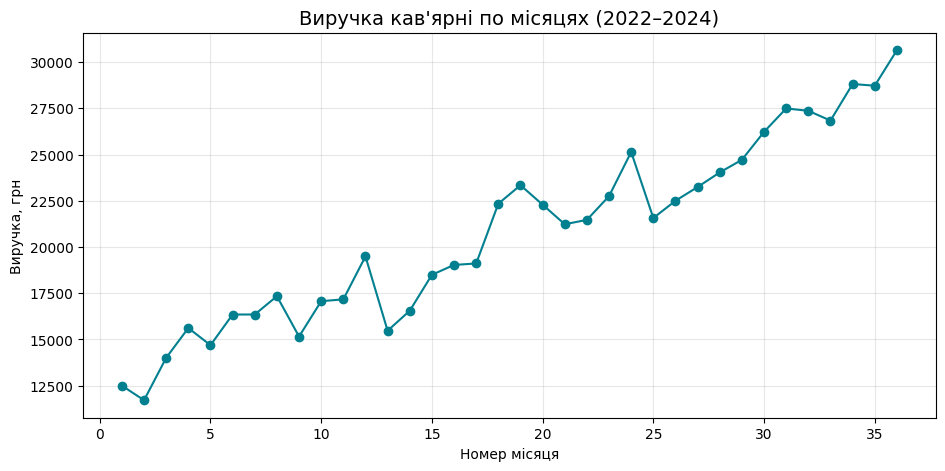

In [ ]:
plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090")
plt.title("Виручка кав'ярні по місяцях (2022–2024)", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 1 (інтерпретація)

Подивіться на графік уважно і дайте відповідь текстом:

1. Який **загальний напрямок** руху виручки? (зростає / падає / стоїть на місці)
2. Чи бачите ви якісь **регулярні коливання** (наприклад, сезонні піки влітку чи взимку)?
3. Як гадаєте, чи можна за таким графіком приблизно вгадати, що буде далі?

**Ваша відповідь:**

1. Виручка чітко **зростає** протягом усіх 36 місяців — з 12 499 грн у січні 2022 до 30 642 грн у грудні 2024. Це майже 2,5-кратне зростання за 3 роки.
2. Так, помітні **регулярні коливання поверх тренду**: кожного року є провал на початку (січень–лютий) і пік ближче до кінця літа/осені (липень–серпень, листопад–грудень). Це схоже на сезонність — можливо, влітку більше людей п'ють каву на вулиці/у кав'ярнях, а взимку продажі трохи просідають після новорічного піку.
3. Так, приблизно можна — тренд настільки стабільний і плавний, що пряму лінію крізь ці точки провести неважко. Але точний прогноз на конкретний місяць буде складніше через сезонні коливання навколо тренду.


## Крок 4. Готуємо дані для моделі

Модель навчається на парах «вхід → вихід». У нас:
- **Вхід (X)** — номер місяця (`month_number`)
- **Вихід (y)** — виручка (`revenue`)

Модель шукатиме залежність: «як виручка залежить від номера місяця».

In [ ]:
# X — вхідні дані (features). Подвійні дужки [[ ]] потрібні, щоб отримати таблицю, а не список
X = df[["month_number"]]

# y — те, що прогнозуємо (target)
y = df["revenue"]

print("X (перші 3):")
print(X.head(3))
print("\ny (перші 3):")
print(y.head(3))

X (перші 3):
   month_number
0             1
1             2
2             3

y (перші 3):
0    12499
1    11712
2    14006
Name: revenue, dtype: int64


## Крок 5. Навчаємо модель

Тепер найголовніше — навчання. Ми використаємо **лінійну регресію** — найпростішу модель, яка проводить пряму лінію крізь наші точки.

Модель за нас знайде два числа:
- **нахил (slope)** — на скільки гривень зростає виручка щомісяця
- **перетин (intercept)** — з якого рівня все починалось

Заповніть один пропуск нижче: викличте `.fit(X, y)`, щоб навчити модель.

In [ ]:
# Створюємо модель
model = LinearRegression()

# Навчаємо модель на наших даних
model.fit(X, y)

print("Модель навчено! ✅")
print(f"Нахил (slope): {model.coef_[0]:.0f} грн на місяць")
print(f"Перетин (intercept): {model.intercept_:.0f} грн")

Модель навчено! ✅
Нахил (slope): 459 грн на місяць
Перетин (intercept): 12247 грн


### ❓ Питання 2 (інтерпретація)

Модель порахувала **нахил (slope)**. Це найважливіше число прогнозу.

1. Чому дорівнює нахил? Що він означає **простими словами** для директора кав'ярні?
   (Підказка: «Щомісяця виручка в середньому зростає на ___ грн»)
2. Перетин (intercept) — це теоретична виручка в «місяць 0». Чи має він реальний бізнес-сенс тут?

**Ваша відповідь:**

1. Нахил дорівнює **≈ 459 грн на місяць**. Простими словами для директора: «Щомісяця виручка кав'ярні в середньому зростає приблизно на 459 грн, і так триває вже 3 роки поспіль».
2. Перетин дорівнює **≈ 12 247 грн**. Формально це прогноз моделі для «місяця 0» — тобто моменту ще до початку наших спостережень. Реального бізнес-сенсу він не має (компанія не існувала в «місяць 0»), це просто математична точка, де пряма лінія перетинає вісь Y. Його не варто інтерпретувати як «стартову виручку» — він потрібен лише для того, щоб побудувати правильну пряму лінію.


## Крок 6. Перевіряємо, як модель описує минуле

Спочатку подивимось, наскільки добре пряма лінія моделі лягає на реальні дані. Побудуємо графік: реальні точки + лінія прогнозу.

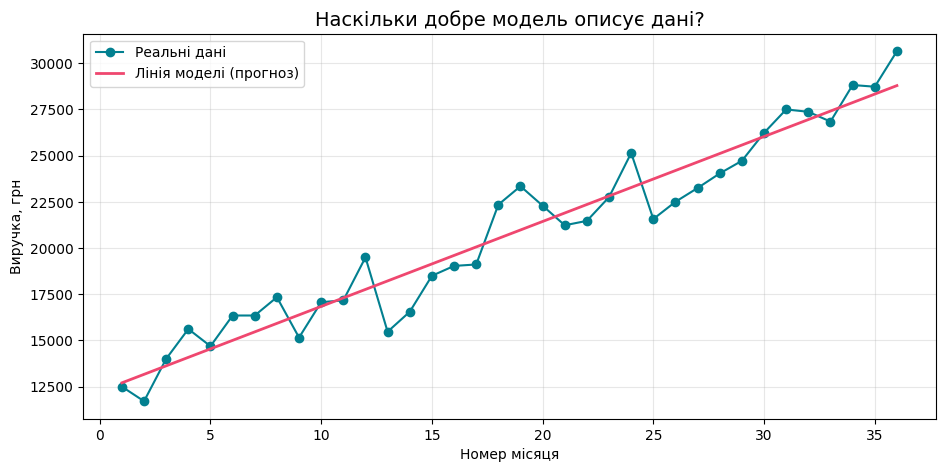

In [ ]:
# Прогноз моделі для всіх наявних місяців
df["predicted"] = model.predict(X)

plt.figure(figsize=(11, 5))
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Реальні дані")
plt.plot(df["month_number"], df["predicted"], color="#EF476F", linewidth=2, label="Лінія моделі (прогноз)")
plt.title("Наскільки добре модель описує дані?", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 3 (інтерпретація)

1. Наскільки добре червона лінія «ловить» загальний тренд синіх точок?
2. Точки не лежать ідеально на лінії — вони то вище, то нижче. **Чому**, на вашу думку? (згадайте про сезонність)
3. Чи вважаєте ви, що проста пряма лінія — це достатньо добре для директора, чи потрібна складніша модель?

**Ваша відповідь:**

1. Дуже добре — лінія проходить точно крізь центр «хмари» точок, і модель пояснює близько 93% варіації виручки (R² ≈ 0.93). Загальний висхідний тренд лінія вловлює майже ідеально.
2. Точки коливаються навколо лінії через **сезонність**, яку пряма лінія в принципі не вміє відображати: вона враховує лише «номер місяця», а не «зима це чи літо». Тому в місяці з сезонним піком (наприклад, серпень) реальні продажі вищі за лінію, а в місяці із сезонним провалом (наприклад, лютий) — нижчі.
3. Для загального орієнтиру («куди рухається бізнес») пряма лінія цілком підходить — вона проста, зрозуміла і добре описує тренд. Але якщо директору потрібен точний прогноз на конкретний місяць (наприклад, «скільки буде у грудні»), варто б додати сезонну складову — просту лінійну регресію тут вже недостатньо.


## Крок 7. 🔮 Прогноз на майбутнє

А тепер — головне, заради чого все робилось. Спрогнозуємо виручку на **наступні 6 місяців** (місяці 37–42, тобто перша половина 2025 року).

Заповніть пропуск: створіть список майбутніх номерів місяців від 37 до 42.

In [ ]:
# Майбутні місяці: 37, 38, 39, 40, 41, 42
future_months = pd.DataFrame({"month_number": [37, 38, 39, 40, 41, 42]})

# Прогнозуємо виручку для них
future_predictions = model.predict(future_months)

# Показуємо результат
for m, pred in zip(future_months["month_number"], future_predictions):
    print(f"Місяць {m}: прогноз ≈ {pred:.0f} грн")

Місяць 37: прогноз ≈ 29242 грн
Місяць 38: прогноз ≈ 29701 грн
Місяць 39: прогноз ≈ 30161 грн
Місяць 40: прогноз ≈ 30620 грн
Місяць 41: прогноз ≈ 31079 грн
Місяць 42: прогноз ≈ 31539 грн


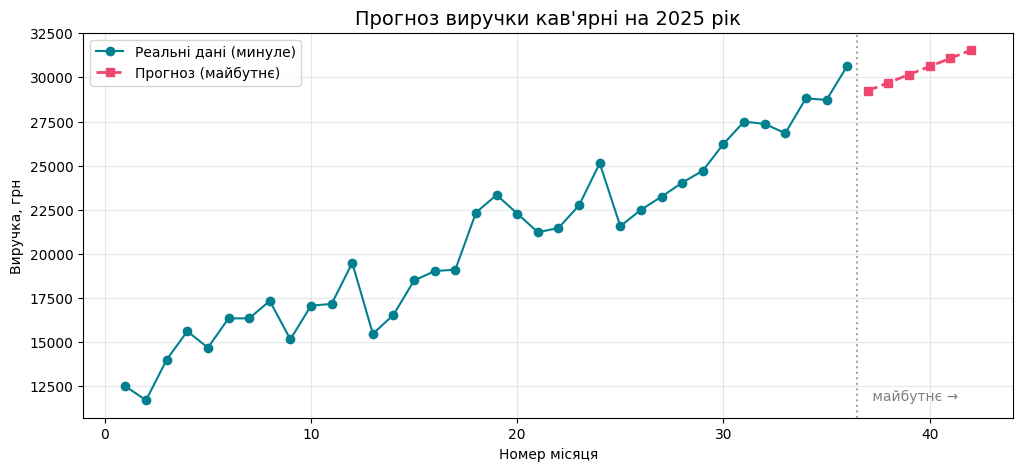

In [ ]:
# Побудуємо фінальний графік: минуле + прогноз
plt.figure(figsize=(12, 5))

# Реальні дані
plt.plot(df["month_number"], df["revenue"], marker="o", color="#028090", label="Реальні дані (минуле)")

# Прогноз на майбутнє
plt.plot(future_months["month_number"], future_predictions,
         marker="s", color="#EF476F", linewidth=2, linestyle="--", label="Прогноз (майбутнє)")

plt.axvline(x=36.5, color="gray", linestyle=":", alpha=0.7)
plt.text(37, df["revenue"].min(), " майбутнє →", color="gray")
plt.title("Прогноз виручки кав'ярні на 2025 рік", fontsize=14)
plt.xlabel("Номер місяця")
plt.ylabel("Виручка, грн")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### ❓ Питання 4 (інтерпретація — найважливіше!)

1. Яку виручку модель прогнозує на **місяць 42** (червень 2025)?
2. Директор питає: «**Чи можна повністю довіряти цьому прогнозу?**» Що ви відповісте? Назвіть хоча б **дві причини**, чому реальність може відрізнятись від прогнозу.
3. Наша модель малює **пряму лінію** — вона припускає, що зростання триватиме вічно тим самим темпом. У яких ситуаціях це припущення може бути **небезпечним** для бізнесу?

**Ваша відповідь:**

1. На місяць 42 (червень 2025) модель прогнозує виручку **≈ 31 539 грн**.
2. Ні, повністю довіряти не можна. Дві (і більше) причини:
   - **Сезонність не врахована.** Модель бачить лише номер місяця, а не пору року, тож не «знає», що червень — це літній місяць із традиційно вищими продажами; реальна цифра може бути помітно вищою або нижчою за пряму лінію.
   - **Екстраполяція за межі даних.** Модель навчалась на місяцях 1–36, а прогнозує на 42-й — це вже поза межами того, що вона «бачила». Будь-які зміни в бізнесі (нова конкуренція, зміна цін, економічна криза, відкриття/закриття точок) модель передбачити не може, бо вона просто продовжує стару пряму лінію.
3. Припущення про «вічне зростання тим самим темпом» небезпечне, коли:
   - Ринок наближається до **насичення** (не може ж виручка зростати нескінченно — рано чи пізно попит вирівняється).
   - Плануються **великі одноразові зміни** (відкриття/закриття філій, вихід конкурента, економічна рецесія) — лінія цього не «побачить».
   - Прогноз використовують для **довгострокових фінансових рішень** (наприклад, взяти кредит під очікуване зростання) — якщо тренд сповільниться чи розвернеться, а рішення вже прийняті на основі прямої лінії, це може призвести до фінансових проблем.


## Крок 8. ⭐ Бонусне завдання (необов'язкове)

Спробуйте спрогнозувати виручку на **один конкретний місяць** — наприклад, місяць 50 (лютий 2026).

Підказка: скопіюйте логіку з Кроку 7, але передайте лише одне число.

In [ ]:
# Ваш експеримент тут:
one_month = pd.DataFrame({"month_number": [50]})
prediction = model.predict(one_month)
print(f"Прогноз на місяць 50: {prediction[0]:.0f} грн")

# ❓ Питання-бонус: чим ДАЛІ в майбутнє ми прогнозуємо, тим прогноз...
#    (надійніший чи менш надійний?) Чому? Напишіть відповідь коментарем нижче:
# Відповідь: Менш надійний. Модель екстраполює пряму лінію все далі за межі даних, на яких вона навчалась (місяці 1-36),
# і не враховує сезонність та можливі зміни в бізнесі. Місяць 50 - це на 14 місяців далі за останні відомі дані,
# тож похибка накопичується сильніше, ніж для місяця 42.

Прогноз на місяць 50: 35213 грн


## 🎓 Підсумок

Вітаємо! Ви щойно:
- ✅ Завантажили й дослідили реальні дані
- ✅ Навчили модель машинного навчання (лінійну регресію)
- ✅ Зробили прогноз на майбутнє
- ✅ **Найголовніше — навчились інтерпретувати результати й розуміти обмеження моделі**

### Що здати
Збережіть цей ноутбук з **усіма відповідями** на питання 1–4 (і бонус) та надішліть викладачу.

### Головний урок
Модель — це лише інструмент. Її прогноз рівно настільки хороший, наскільки хороші дані й наскільки розумно ви інтерпретуєте результат. **Аналітик, який розуміє обмеження моделі, цінніший за того, хто просто вміє натиснути `.fit()`.**